## CNN

Источники:

https://machinelearningmastery.com/building-a-convolutional-neural-network-in-pytorch/

https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data

https://github.com/MicrosoftDocs/ml-basics/blob/master/05b%20-%20Convolutional%20Neural%20Networks%20(PyTorch).ipynb

Оригинальный датасет: https://www.kaggle.com/datasets/likhon148/animal-data

In [1]:
import torch.nn as nn
import torch.optim as optim
import torchvision

In [2]:
import torch

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
from torchvision import datasets, transforms

In [6]:
from tqdm import tqdm

In [7]:
import torch.nn.functional as F

Загрузим данные. Нам необходимо, чтобы картинки были одинакового размера, поэтому при загрузке применим к ним преобразование, которое будет превращать исходные картинки в изображения размером 128*128 пикселей.

In [8]:
transform = transforms.Compose([transforms.Resize(128),
                                 transforms.ToTensor()])

In [9]:
dataset_animals = datasets.ImageFolder('/content/drive/MyDrive/ML_training_data/animals', transform=transform)

In [10]:
dataset_animals

Dataset ImageFolder
    Number of datapoints: 383
    Root location: /content/drive/MyDrive/ML_training_data/animals
    StandardTransform
Transform: Compose(
               Resize(size=128, interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [11]:
dataset_animals.class_to_idx

{'Cat': 0, 'Lion': 1, 'Tiger': 2}

In [12]:
len(dataset_animals)

383

Разделим картинки на тренировочные и тестовые:

In [ ]:
#train_set, val_set = torch.utils.data.random_split(dataset_animals, [300, 83])

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
train_idx, validation_idx = train_test_split(np.arange(len(dataset_animals)),
                                             test_size=83,
                                             random_state=0,
                                             shuffle=True,
                                             stratify=dataset_animals.targets)

train_dataset = torch.utils.data.Subset(dataset_animals, train_idx)
validation_dataset = torch.utils.data.Subset(dataset_animals, validation_idx)

Мы будем работать с даталоадерами - объектами, позволяющими итерироваться по тренировочным и тестовым сабсетам, которые удобно подавать в модель:

In [16]:
dataloader_train = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(validation_dataset, batch_size=32, shuffle=True)

Во время прохода по даталоадеру каждую итерацию мы будем получать минибатч фиксированной длины batch_size. Минибатч состоит из некоторого количества картинок и их лейблов. Возьмем для примера один минибатч и посмотрим на него:

In [18]:
images, labels = next(iter(dataloader_train))

In [19]:
# лейблы картинок в минибатче
labels

tensor([0, 2, 2, 2, 1, 2, 1, 1, 0, 2, 1, 0, 1, 1, 0, 1, 2, 2, 2, 2, 0, 1, 0, 2,
        1, 0, 1, 2, 2, 2, 2, 1])

In [20]:
len(labels)

32

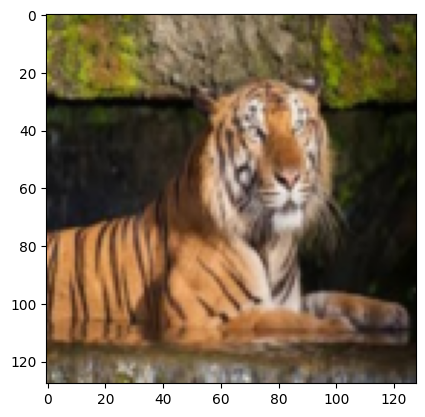

In [21]:
# одна из картинок минибатча (всего их число равно batch_size)
fig, ax = plt.subplots()
image = images[3].numpy().transpose((1, 2, 0))
ax.imshow(image)

In [23]:
# в картинке размером 128х128 пикселей три цветовых канала
images[3]

tensor([[[0.5529, 0.5490, 0.4941,  ..., 0.2275, 0.2000, 0.2078],
         [0.4863, 0.4431, 0.4902,  ..., 0.2078, 0.2510, 0.2392],
         [0.4235, 0.4863, 0.4667,  ..., 0.2118, 0.2353, 0.1922],
         ...,
         [0.4941, 0.4157, 0.6980,  ..., 0.2627, 0.2510, 0.2275],
         [0.5098, 0.3922, 0.5922,  ..., 0.2706, 0.2471, 0.2314],
         [0.4392, 0.3412, 0.4000,  ..., 0.3176, 0.2588, 0.2392]],

        [[0.6353, 0.6078, 0.5176,  ..., 0.2000, 0.1804, 0.1843],
         [0.5647, 0.5020, 0.5137,  ..., 0.1804, 0.2235, 0.2118],
         [0.4863, 0.5294, 0.4745,  ..., 0.1922, 0.2157, 0.1686],
         ...,
         [0.4549, 0.3882, 0.6863,  ..., 0.2431, 0.2353, 0.2157],
         [0.4667, 0.3647, 0.5765,  ..., 0.2667, 0.2431, 0.2275],
         [0.3922, 0.3059, 0.3804,  ..., 0.3176, 0.2627, 0.2392]],

        [[0.1255, 0.1608, 0.1882,  ..., 0.1176, 0.0745, 0.0784],
         [0.0706, 0.0549, 0.1765,  ..., 0.1059, 0.1451, 0.1373],
         [0.0549, 0.1373, 0.1765,  ..., 0.1059, 0.1451, 0.

### Нейросеть

Мы создадим обычную сверточную нейросеть для классификации изображений с двумя сверточными слоями. Применим один раз дропаут и один раз пулинг.

In [24]:
class ImageCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=3, stride=1, padding=1)
        self.act1 = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3, stride=1, padding=1)
        self.act2 = nn.ReLU()
        self.drop = nn.Dropout2d(p=0.2)

        # Для создания выходного слоя нам нужно заранее знать размерность, которую выдает последний скрытый слой.
        # Перед выходным слоем мы сделаем выдачу последней свертки плоской (см. ниже)
        # Поскольку мы один раз применяем pooling=2, измерения наших картинкок уменьшатся с 128 до 64
        # Число же выходных каналов последней свертки равно 24
        # В результате нам нужно получить 3 колонки вероятностей по числу категорий
        self.fc = nn.Linear(in_features=64 * 64 * 24, out_features=3)

    def forward(self, x):

        # первая свертка
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool(x)

        # вторая свертка
        x = self.conv2(x)
        x = self.act2(x)
        x = self.drop(x)

        # превращение последеней свертки в плоский тензор
        x_viewed = x.view(-1, 64 * 64 * 24)

        x = self.fc(x_viewed)

        return x

### По шагам:

Давайте посмотрим, что происходит с данными, поданными в модель, по шагам. Помните, что это только forward pass: обратный проход будет потом, во время тренировки.

Сначала убедимся, что класс модели написан правильно. Сделаем объект модели подобно тому, как делали объекты моделей в sklearn:

In [25]:
model = ImageCNN().to(device)

Выполним forward pass модели. Так как мы ее еще не обучали, веса в ней инициализированы случайно, поэтому хороших предсказаний не будет.

In [26]:
probs = model(images.to(device))

Получаем вектор размерностью (размер минибатча*количество классов):

In [27]:
probs.size()

torch.Size([32, 3])

То, что мы получили, называется **логитами** - финальными предсказаниями модели, еще не прошедшими через последнюю функцию активации. Мы не используем активацию на последнем слое, т.к. хотим применить CrossEntropyLoss, который содержит софтмакс-активацию внутри себя.

In [29]:
labels[:10]

tensor([0, 2, 2, 2, 1, 2, 1, 1, 0, 2])

In [28]:
# посмотрим на вероятности каждого класса
probs[:10]

tensor([[ 0.0709, -0.0194,  0.0007],
        [ 0.0827, -0.0119, -0.0180],
        [ 0.1123, -0.0080, -0.0320],
        [ 0.0766, -0.0010, -0.0006],
        [ 0.0340, -0.0629, -0.0458],
        [-0.0128,  0.0139, -0.0016],
        [ 0.0044,  0.0290, -0.0007],
        [ 0.0110,  0.0060, -0.0085],
        [ 0.0337,  0.0382,  0.0370],
        [ 0.0662, -0.0199, -0.0021]], device='cuda:0',
       grad_fn=<SliceBackward0>)

Наша первая свертка принимает входное изображение, состоящее из трех каналов input_channels, и преобразовывает его в 12 каналов (out_channels). Ядро свертки имеет размерность 3 (kernel_size), шаг 1 и паддинг 1.

In [30]:
conv1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=3, stride=1, padding=1).to(device)

Пулинг-слой будет снижать размерность свертки в два раза.

In [31]:
pool = nn.MaxPool2d(kernel_size=2).to(device)

Следующая свертка принимает результаты предыдущей, поэтому в ней 12 входных каналов. Она переведет их в 24:

In [32]:
conv2 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3, stride=1, padding=1).to(device)

Дропаут регуляризует нашу нейросеть:

In [33]:
drop = nn.Dropout2d(p=0.2).to(device)

Возьмем наш минибатч картинок и посмотрим, как они изменятся в процессе forward pass'a нейросети:

In [34]:
x = images.to(device)

In [35]:
x.size()

torch.Size([32, 3, 128, 128])

In [36]:
x = conv1(x)

In [37]:
x.size()

torch.Size([32, 12, 128, 128])

In [38]:
x = pool(x)

In [39]:
x.size()

torch.Size([32, 12, 64, 64])

In [40]:
x = conv2(x)

In [41]:
x.size()

torch.Size([32, 24, 64, 64])

Итак, у нас есть четырехмерный выход сверточных слоев. Но для того, чтобы получить вероятности классов, нам нужна двумерная матрица. Поэтому мы сначала при помощи метода .view() уменьшим размерность, а затем при помощи полносвязного слоя достанем логиты:

In [42]:
x = x.view(-1, 64 * 64 * 24)

In [43]:
x.size()

torch.Size([32, 98304])

In [44]:
fc = nn.Linear(in_features=64 * 64 * 24, out_features=3).to(device)

In [45]:
x = fc(x)

In [46]:
x.size()

torch.Size([32, 3])

### Обучение

Нередко в нейросетях считают accuracy, а не f1-score, когда оценивают качество на каждой эпохе. В этот раз мы тоже так сделаем.

In [47]:
from sklearn.metrics import accuracy_score

Определим функцию потерь и метод оптимизации:

In [48]:
loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-4)

Мы будем тренироваться 25 эпох.

In [49]:
n_epochs = 25

for epoch in tqdm(range(n_epochs)):

    epoch_loss = []

    for inputs, labels in dataloader_train:

        optimizer.zero_grad()

        y_pred = model(inputs.to(device))
        loss = loss_fn(y_pred.to(device), labels.to(device))

        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())

    acc_scores = []

    # будем сразу на каждой эпохе делать предсказания на тестовом сете и смотреть на качество
    for inputs, labels in dataloader_val:
        y_pred_probs = model(inputs.to(device))
        current_y_pred = torch.argmax(y_pred_probs, 1)
        acc_scores.append(accuracy_score(labels.cpu(), current_y_pred.cpu()))

    avg_acc = np.mean(acc_scores)

    print('Epoch {0}, loss {1}, accuracy {2}'.format(epoch, sum(epoch_loss)/len(epoch_loss), avg_acc))
    epoch_loss = []

  4%|▍         | 1/25 [05:31<2:12:35, 331.48s/it]

Epoch 0, loss 1.2255139172077179, accuracy 0.3514254385964912


  8%|▊         | 2/25 [05:33<52:40, 137.41s/it]  

Epoch 1, loss 1.0771136999130249, accuracy 0.43201754385964913


 12%|█▏        | 3/25 [05:34<27:38, 75.38s/it] 

...

Epoch 22, loss 0.25948064029216766, accuracy 0.7149122807017544


 96%|█████████▌| 24/25 [06:09<00:01,  1.73s/it]

Epoch 23, loss 0.2887302219867706, accuracy 0.6655701754385964


100%|██████████| 25/25 [06:11<00:00, 14.85s/it]

Epoch 24, loss 0.280814328789711, accuracy 0.6546052631578947


## RNN

Продолжаем изучать классификацию имен по [этому](https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html) туториалу.

Предобработку берем с прошлого раза.

In [50]:
import os
from collections import defaultdict

In [51]:
from tqdm import tqdm

In [52]:
import random

In [53]:
import torch

In [54]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [55]:
category_lines = defaultdict(list)

for filename in os.listdir('/content/drive/MyDrive/ML_training_data/names'):
  category_name = filename[:-4]
  with open(os.path.join('/content/drive/MyDrive/ML_training_data/names', filename), 'r') as f:
    lines = f.read().strip().split('\n')
    category_lines[category_name] = lines

In [56]:
category_lines.keys()

dict_keys(['Chinese', 'Arabic', 'Czech', 'German', 'Korean', 'Japanese', 'Dutch', 'Polish', 'French', 'Greek', 'Portuguese', 'Scottish', 'Irish', 'Spanish', 'English', 'Italian', 'Vietnamese', 'Russian'])

In [57]:
unique_letters = set()

for k, v in category_lines.items():
  for word in v:
    unique_letters.update(set(word))

In [58]:
all_letters_list = list(unique_letters)
all_letters = ''.join(all_letters_list)
n_letters = len(all_letters)

In [59]:
n_letters += 1

In [60]:
all_categories = list(category_lines.keys())
n_categories = len(all_categories)

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device available for running: ")
print(device)

Device available for running: 
cuda


В этот раз закодируем имена по-другому: каждому имени поставим в соответствие вектор размерности (количество букв\*1\*количество уникальных символов). Единица посередине нужна, чтобы притвориться, что каждый вектор является минибатчем размерностью 1 (технический момент для пайторча). Каждый раз, когда мы создаем какой-нибудь тензор, мы сначала создаем тензор из нулей при помощи функции torch.zeros(), а потом заполняем его числами.

In [62]:
def letterToIndex(letter):
    # преобразование буквы в индекс
    return all_letters.find(letter)


def letterToTensor(letter):
    # преобразование буквы в тензор
    tensor = torch.zeros(1, n_letters)
    if letter in all_letters:
      tensor[0][letterToIndex(letter)] = 1
    else:
      tensor[0][-1] = 1
    return tensor


def lineToTensor(line):
    # преобразование имени в тензор
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor.to(device)


print('7:\n', letterToTensor('7'))
print('Zahar\n', lineToTensor('Zahar'))
print('Zahar - tensor size\n', lineToTensor('Zahar').size())

7:
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])
Zahar
 tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0

### Нейросеть

Мы инициализируем рекуррентную нейросеть как обычную с одним входным слоем, двумя скрытыми и одним выходным. Мы будем делать forward pass по входному и скрытому слою, затем суммировать их веса и применять к ним функцию активации, получая скрытые состояния. Их мы затем передадим в выходной слой и примерим софтмакс, т.к. у нас по-прежнему многоклассовая классификация.

In [63]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        self.init_to_hidden = nn.Linear(input_size, hidden_size)
        self.hidden_to_hidden = nn.Linear(hidden_size, hidden_size)
        self.hidden_to_output = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        hidden = F.tanh(self.init_to_hidden(input) + self.hidden_to_hidden(hidden))
        output = self.hidden_to_output(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        # поскольку нам нужно чем-то заполнить скрытый слой при самом первом проходе, мы инициализируем его нулями
        return torch.zeros(1, self.hidden_size)

### По шагам

Сначала инициализируем объект модели и посмотрим, что она работает.

In [64]:
n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories).to(device)

Наша рекуррентная нейросеть будет идти по каждой букве слова, сохраняя информацию о предыдущих буквах, чтобы затем сделать предсказание категории, когда буквы закончатся. Давайте попробуем пройтись только по одной букве:

In [65]:
input = lineToTensor('Zahar')
# перед предсказанием каждого слова нам нужно не только превратить слово в тензор, но и инициализировать скрытый слой:
hidden = rnn.initHidden()

output, next_hidden = rnn(input[0].to(device), hidden.to(device))
print(output)

tensor([[-2.8378, -2.9087, -2.9022, -2.9505, -2.8488, -2.9514, -2.8138, -2.7146,
         -2.9308, -2.8229, -2.9364, -2.9759, -2.8386, -2.9258, -2.9196, -2.9685,
         -2.9123, -2.9069]], device='cuda:0', grad_fn=<LogSoftmaxBackward0>)


Теперь мы получили уже не логиты, а полноценные предсказания, так как внутри модели есть финальная функция активации - LogSoftmax. Но мы пока что не обучались, так что предсказания не очень хороши.

Если ориентироваться на эту картинку из презентации (Bao et al., 10.1371/journal.pone.0180944), выход output соответствует Ot-1, а скрытое состояние next_hidden - St-1:

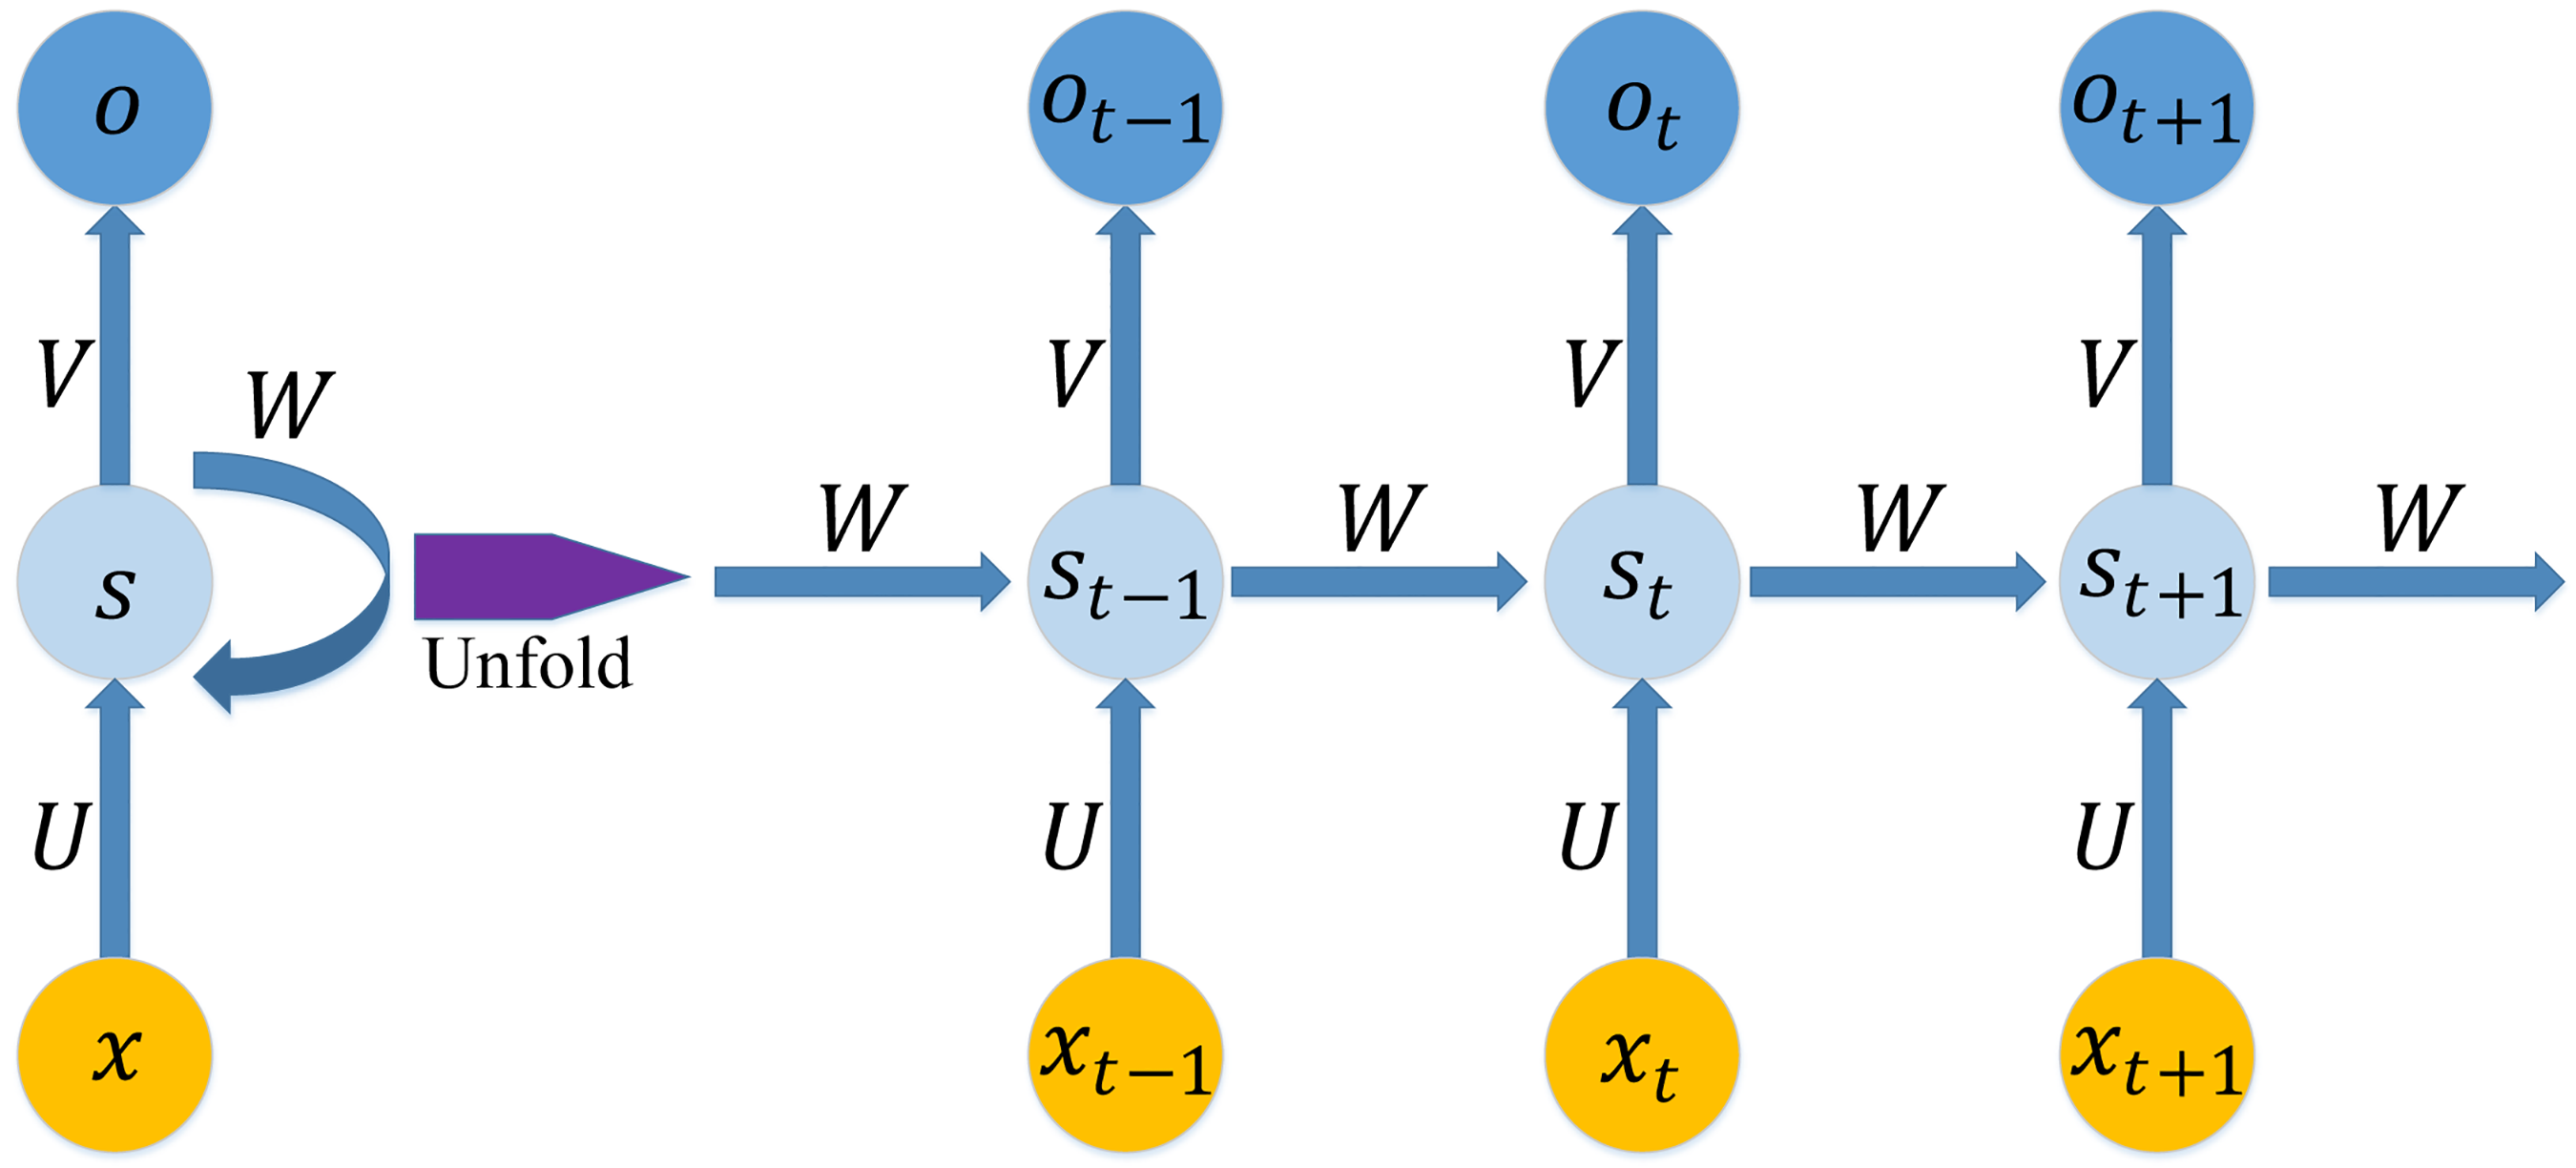

Можно убедиться, что мы получили тот же результат, как если бы подали в нейросеть одну только букву Z:

In [66]:
input = letterToTensor('Z')
hidden = rnn.initHidden()

output, next_hidden = rnn(input.to(device), hidden.to(device))

In [67]:
output

tensor([[-2.8378, -2.9087, -2.9022, -2.9505, -2.8488, -2.9514, -2.8138, -2.7146,
         -2.9308, -2.8229, -2.9364, -2.9759, -2.8386, -2.9258, -2.9196, -2.9685,
         -2.9123, -2.9069]], device='cuda:0', grad_fn=<LogSoftmaxBackward0>)

Давайте разберемся, что происходит внутри нейросети, на примере одной буквы.

In [68]:
# инициализируем начальное скрытое состояние
hidden_0 = torch.zeros(1, n_hidden)

Во-первых, нам нужно два линейных слоя: один, init_to_hidden, будет принимать закодированную входную букву, второй, hidden_to_hidden, будет принимать скрытое состояние. Во-вторых, нам нужен выходной слой hidden_to_output.

In [69]:
input_size = n_letters
hidden_size = n_hidden
output_size = n_categories

init_to_hidden = nn.Linear(input_size, hidden_size).to(device)
hidden_to_hidden = nn.Linear(hidden_size, hidden_size).to(device)
hidden_to_output = nn.Linear(hidden_size, output_size).to(device)

In [70]:
# сам входной вектор буквы выглядит так
input

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Пропустим входную букву и начальное скрытое состояние через соответствующие слои:

In [71]:
input = init_to_hidden(input.to(device))

In [72]:
input.size()

torch.Size([1, 128])

In [73]:
hidden = hidden_to_hidden(hidden_0.to(device))

In [74]:
hidden.size()

torch.Size([1, 128])

Затем нам нужно просуммировать информацию, полученную от текущей буквы (input) и "контекстную" информацию hidden (хотя никакого контекста мы еще, конечно же, не знаем):

In [75]:
sum_i_h = input + hidden

In [76]:
sum_i_h.size()

torch.Size([1, 128])

И применить функцию активации:

In [77]:
activated = F.tanh(input + hidden)

In [78]:
activated.size()

torch.Size([1, 128])

Затем можно получать выходы нейросети и превращать их в вероятности при помощи софтмакса:

In [79]:
output = hidden_to_output(activated)

In [80]:
output.size()

torch.Size([1, 18])

In [81]:
softmax = nn.LogSoftmax(dim=1)

In [82]:
probs = softmax(output)

In [83]:
probs

tensor([[-2.8665, -2.8339, -2.9129, -2.9220, -2.9182, -2.8742, -2.7728, -2.9624,
         -2.8508, -2.8992, -2.9400, -2.8172, -2.9110, -2.8242, -2.8433, -2.9973,
         -2.9888, -2.9240]], device='cuda:0', grad_fn=<LogSoftmaxBackward0>)

Мы получили немного другой вектор, чем тот, что выше, поскольку инициализировали все слои заново.

Теперь нам нужно еще написать функцию, которая будет превращать выданные вероятности (probs) в лейбл предсказанной категории:

In [84]:
def categoryFromOutput(output):
    # перевод выданных вероятностей в категорию
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

print(categoryFromOutput(probs))

('Dutch', 6)


In [85]:
probs.topk(1)

torch.return_types.topk(
values=tensor([[-2.7728]], device='cuda:0', grad_fn=<TopkBackward0>),
indices=tensor([[6]], device='cuda:0'))

Разделение на тестовую и тренировочную выборку:

In [86]:
from sklearn.model_selection import train_test_split

In [87]:
X = []
y = []

for k, v in category_lines.items():
  for w in v:
    X.append(w)
    y.append(k)

In [88]:
len(X) == len(y)

True

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, shuffle=True)

### Обучение

Объявим наши гиперпараметры: размерность входного слоя (идентична количеству уникальных букв), размерность скрытого слоя (может быть любой), размерность выходного слоя (равна количеству категорий), количество эпох, learning rate и размер батча (могут быть любыми).

In [90]:
input_dim = n_letters
hidden_dim = 128
output_dim = len(all_categories)
num_epochs = 100
learning_rate = 3e-4
batch_size = 1000

Передадим все параметры в модель, выберем функцию потерь и оптимайзер и начнем обучение.

In [91]:
rnn_model = RNN(input_dim, 128, output_dim).to(device)

In [92]:
loss_function = nn.NLLLoss().to(device)
optimizer = optim.Adam(rnn_model.parameters(), lr=learning_rate)

In [93]:
losses = []

for epoch in tqdm(range(num_epochs)):
    train_loss = 0

    current_batch = random.sample(range(len(X_train)), batch_size)
    current_X_train = [X_train[i] for i in current_batch]
    current_y_train = [y_train[i] for i in current_batch]

    for current_word, current_category in zip(current_X_train, current_y_train):

      hidden = rnn.initHidden()

      # Очищаем градиент, аккумулированный на предыдущих этапах
      optimizer.zero_grad()

      # кодируем имя и категорию, превращая их в тензоры
      line_tensor = lineToTensor(current_word)
      category_tensor = torch.tensor([all_categories.index(current_category)], dtype=torch.long)

      # forward pass: идем по каждой букве, обновляем веса и получаем вероятности классов для слова
      for i in range(line_tensor.size()[0]):
        output, hidden = rnn_model(line_tensor[i].to(device), hidden.to(device))

      # считаем значение функции потерь и добавляем его к общему лоссу этой эпохи
      loss = loss_function(output, category_tensor.to(device))
      train_loss += loss.item()

      # backward pass: распространяем ошибку обратно, чтобы проапдейтить веса
      loss.backward()

      # Апдейтим веса
      optimizer.step()

    losses.append(train_loss/batch_size)

    print('Epoch {0}, loss {1}'.format(epoch, train_loss/batch_size))

    # перед следующей эпохой зануляем лосс
    train_loss = 0

  1%|          | 1/100 [00:04<07:18,  4.43s/it]

Epoch 0, loss 1.7365616493076086


  2%|▏         | 2/100 [00:08<06:43,  4.12s/it]

Epoch 1, loss 1.588171464862302


  3%|▎         | 3/100 [00:12<06:48,  4.21s/it]

...

Epoch 97, loss 0.5709200316647057


 99%|█████████▉| 99/100 [06:59<00:04,  4.15s/it]

Epoch 98, loss 0.5987341728302381


100%|██████████| 100/100 [07:04<00:00,  4.24s/it]

Epoch 99, loss 0.598350537648239


Оценим качество тренировки и предсказаний: посмотрим на график лосса и classification_report.

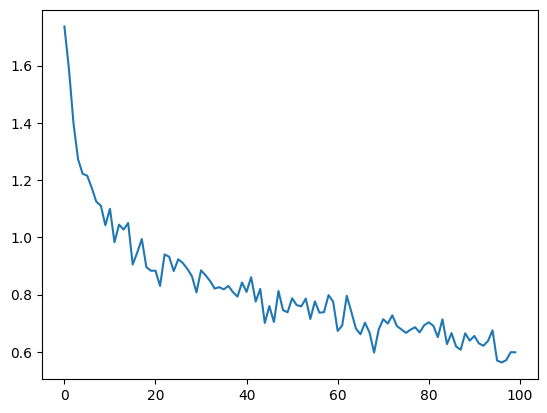

In [94]:
import matplotlib.pyplot as plt

plt.plot(losses)

In [95]:
from sklearn.metrics import classification_report

rnn_predictions = []
original_lables = []

# этот метод означает, что нам не нужно считать градиент для обратного распространения ошибки, а нужно сделать только предсказания
with torch.no_grad():
  for word, cat in zip(X_test, y_test):
    line_tensor = lineToTensor(word)

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn_model(line_tensor[i], hidden)

    current_cat, cat_label = categoryFromOutput(output)
    rnn_predictions.append(cat_label)
    original_lables.append(all_categories.index(cat))

In [96]:
print(classification_report(original_lables, rnn_predictions, target_names=all_categories))

              precision    recall  f1-score   support

     Chinese       0.33      0.06      0.10        67
      Arabic       0.67      0.11      0.19       500
       Czech       0.00      0.00      0.00       130
      German       0.00      0.00      0.00       181
      Korean       0.00      0.00      0.00        24
    Japanese       0.33      0.86      0.47       248
       Dutch       0.00      0.00      0.00        74
      Polish       0.00      0.00      0.00        35
      French       0.00      0.00      0.00        69
       Greek       0.35      0.18      0.23        51
  Portuguese       0.00      0.00      0.00        18
    Scottish       0.00      0.00      0.00        25
       Irish       0.00      0.00      0.00        58
     Spanish       0.00      0.00      0.00        75
     English       0.86      0.01      0.03       917
     Italian       1.00      0.01      0.01       177
  Vietnamese       0.00      0.00      0.00        18
     Russian       0.54    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


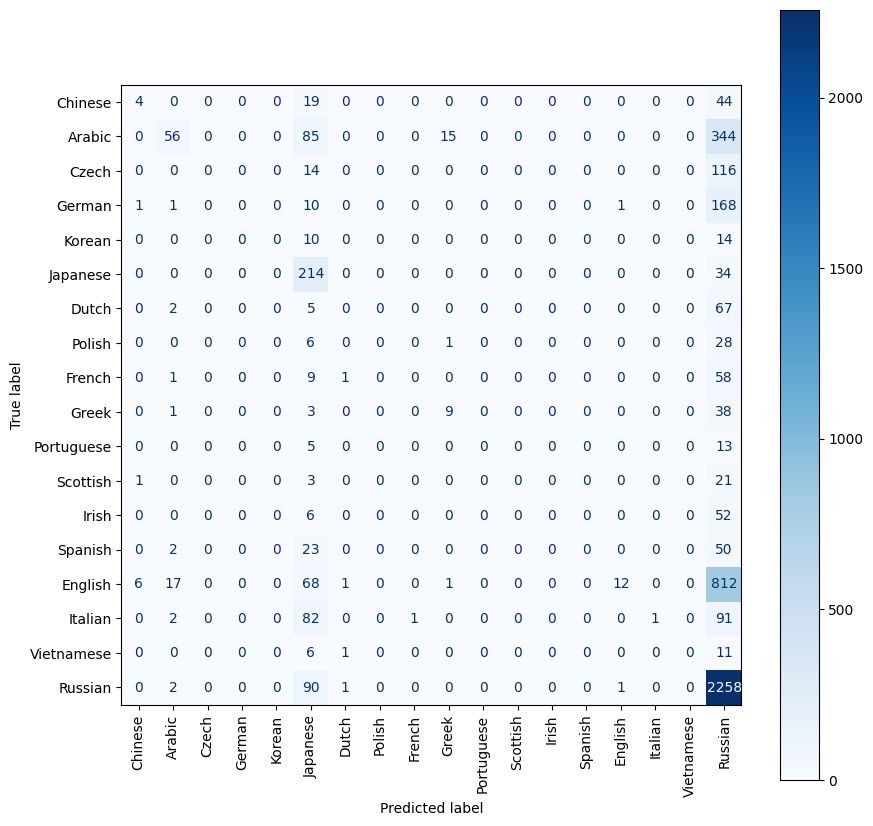

In [97]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(original_lables,
                                        rnn_predictions,
                                        display_labels=all_categories,
                                        ax=ax,
                                        xticks_rotation='vertical', cmap='Blues')